In [1]:
import os
import math
import warnings
from typing import Optional, Tuple, Dict, Union

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.axes

from google.colab import drive

plt.style.use("seaborn-v0_8")
#plt.style.use("ggplot")

FigAx = Tuple[plt.Figure, matplotlib.axes.Axes]

drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
%cd /content/drive/MyDrive/Portfolio_WL/Gains_chart/app/src

/content/drive/.shortcut-targets-by-id/1_AIT01GzQv6t0g05WUfHQW5kZKXctlJl/Portfolio_WL/Gains_chart/app/src


In [3]:
# Chamada dos arquivos auxiliares .py
from cap_example_models import _load_data, train_models, data_path, target_col
from utils_poo import analyze_multiple_models, compute_ks_curves, compute_roc_curves
from utils_llm_poo import describe_gain_credit_chart, client

1.6.1
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
utils_poo carregado


In [ ]:
# %run /content/drive/MyDrive/Portfolio_WL/Gains_chart/app/notebooks/cap_example_models.ipynb
# ↑ executa o treinamento → df, results, data_path, target_col disponíveis no namespace

# df = _load_data(data_path)

# results = train_models(df, target_col)

# assert len(results['y_test']) == len(results['Logistic Regression']['proba_test'])
# assert len(results['y_test']) == len(results['Random Forest']['proba_test'])

# Save

In [ ]:
# df_results_ord = pd.DataFrame({
#     "y_true": results["y_test"],
#     "proba_logistic": results["Logistic Regression"]["proba_test"],
#     "proba_rf": results["Random Forest"]["proba_test"]
# })
# df_results_ord.head()

# path_csv = "/content/drive/MyDrive/Portfolio_WL/Gains_chart/app/data/predicoes_modelos.csv"
# df_results_ord.to_csv(path_csv, index=False, sep=";")

In [4]:
results = pd.read_csv("/content/drive/MyDrive/Portfolio_WL/Gains_chart/app/data/predicoes_modelos.csv",
                      sep = ";")

results["proba_logistic"] = 1 - results["proba_logistic"]
results["proba_rf"] = 1 - results["proba_rf"]

scores_dict = {
    "Logistic Regression": results["proba_logistic"],
    "Random Forest":    results["proba_rf"],
}

target = results["y_true"]

In [5]:
# %run /content/drive/MyDrive/Portfolio_WL/Gains_chart/app/notebooks/utils_poo.ipynb
# ↑ expõe: CreditScoreAnalysis, analyze_multiple_models, compute_roc_curves, compute_ks_curves

# Inputs para as curvas
# scores_dict = {
#     "Logistic Regression": results["Logistic Regression"]["proba_test"],
#     "Random Forest":    results["Random Forest"]["proba_test"],
# }

# target = results["y_test"]

n_percentiles = 10
results_ord = analyze_multiple_models(scores_dict, target, n_percentiles)
results_ord


,percentile,total,bads,goods,percentile_rev,total_cum,bads_cum,goods_cum,total_rate_cum,gain,...,good_rate_cum,bads_cum_rev,total_cum_rev,bad_rate_cum_rev,lift_rev,gain_rev,bad_rate,percentile_label,percentile_rev_label,model
0,1,3000,787,2213,10,3000,787,2213,0.100000,0.392519,...,0.737667,2005,30000,0.066833,1.000000,1.000000,0.262333,1 - Menos arriscado,10 - Menos arriscado,Logistic Regression
1,2,3000,242,2758,9,6000,1029,4971,0.200000,0.513217,...,0.828500,1218,27000,0.045111,0.674979,0.607481,0.080667,2,9,Logistic Regression
2,3,3000,197,2803,8,9000,1226,7774,0.300000,0.611471,...,0.863778,976,24000,0.040667,0.608479,0.486783,0.065667,3,8,Logistic Regression
3,4,3000,153,2847,7,12000,1379,10621,0.400000,0.687781,...,0.885083,779,21000,0.037095,0.555041,0.388529,0.051000,4,7,Logistic Regression
4,5,3000,134,2866,6,15000,1513,13487,0.500000,0.754613,...,0.899133,626,18000,0.034778,0.520366,0.312219,0.044667,5,6,Logistic Regression
5,6,3000,106,2894,5,18000,1619,16381,0.600000,0.807481,...,0.910056,492,15000,0.032800,0.490773,0.245387,0.035333,6,5,Logistic Regression
6,7,3000,100,2900,4,21000,1719,19281,0.700000,0.857357,...,0.918143,386,12000,0.032167,0.481297,0.192519,0.033333,7,4,Logistic Regression
7,8,3000,71,2929,3,24000,1790,22210,0.800000,0.892768,...,0.925417,286,9000,0.031778,0.475478,0.142643,0.023667,8,3,Logistic Regression
8,9,3000,69,2931,2,27000,1859,25141,0.900000,0.927182,...,0.931148,215,6000,0.035833,0.536160,0.107232,0.023000,9,2,Logistic Regression
9,10,3000,146,2854,1,30000,2005,27995,1.000000,1.000000,...,0.933167,146,3000,0.048667,0.728180,0.072818,0.048667,10 - Mais arriscado,1 - Mais arriscado,Logistic Regression


In [ ]:
# print(f"O DataFrame 'df' possui {df.shape[0]} observações (linhas) e {df.shape[1]} colunas.")

In [6]:
def _save_figure(fig: plt.Figure, output_path: Optional[str]) -> None:
    """Save figure to disk if output_path is provided."""
    if output_path is not None:
        fig.savefig(output_path, dpi=300, bbox_inches="tight")

In [7]:
def _validate_results_percentil(results_percentil: pd.DataFrame, required_cols: list) -> None:
    """Raise ValueError if any required column is missing from results."""
    missing = [col for col in required_cols if col not in results_percentil.columns]
    if missing:
        raise ValueError(
            f"results_percentil is missing required columns: {missing}. "
            "Make sure to pass the output of analyze_multiple_models()."
        )


def _compute_cutoff(n_percentiles: int) -> int:
    """Return the midpoint percentile, warning if n_percentiles is odd."""
    if n_percentiles % 2 != 0:
        warnings.warn(
            f"n_percentiles={n_percentiles} is odd. "
            f"Cutoff will be set to {n_percentiles // 2} (rounded down).",
            UserWarning,
            stacklevel=2,
        )
    return n_percentiles // 2

In [8]:
def _apply_font_sizes(
    ax: matplotlib.axes.Axes,
    title_fontsize: int,
    label_fontsize: int,
    tick_fontsize: int,
    legend_fontsize: int,
) -> None:
    """Apply font size settings to all text elements of an Axes."""
    ax.title.set_fontsize(title_fontsize)
    ax.xaxis.label.set_fontsize(label_fontsize)
    ax.yaxis.label.set_fontsize(label_fontsize)
    ax.tick_params(axis="both", labelsize=tick_fontsize)
    if ax.get_legend() is not None:
        ax.legend(fontsize=legend_fontsize)

In [10]:
def plot_percentil_bad_rate(
    results_percentil: pd.DataFrame,
    target: pd.Series,
    figsize: Tuple[int, int] = (5, 4),
    palette: str = "viridis",
    #title: str = "Ordenação Relativa",
    xlabel: str = "Decil",
    ylabel: str = "Taxa de Mau",
    title_fontsize: int = 12,
    label_fontsize: int = 10,
    tick_fontsize: int = 9,
    legend_fontsize: int = 9,
    output_path: Optional[str] = "grafico_ordena.png",
) -> FigAx:
    """Plot bad rate by percentile for one or more models.

    Parameters
    ----------
    results_percentil : pd.DataFrame
        Output of analyze_multiple_models(), containing columns
        'percentile', 'bad_rate', and 'model'.
    target : pd.Series
        Binary target (1 = bad, 0 = good) used to compute the average
        bad rate reference line.
    figsize : tuple, default=(5, 4)
        Figure dimensions in inches.
    palette : str, default="viridis"
        Seaborn color palette for the model lines.
    title : str, default="Ordenação Relativa"
        Chart title.
    xlabel : str, default="Percentil"
        Label for the x-axis.
    ylabel : str, default="Taxa de Mau"
        Label for the y-axis.
    title_fontsize : int, default=12
        Font size for the chart title.
    label_fontsize : int, default=10
        Font size for axis labels.
    tick_fontsize : int, default=9
        Font size for axis tick labels.
    legend_fontsize : int, default=9
        Font size for legend text.
    output_path : str or None, default="grafico_ordena.png"
        File path to save the figure. Pass None to skip saving.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    _validate_results_percentil(results_percentil, ["percentile", "bad_rate", "model"])

    avg_bad_rate = pd.Series(target).mean() * 100

    results_percentil["bad_rate_aux"] = results_percentil["bad_rate"] * 100

    fig, ax = plt.subplots(figsize=figsize)

    sns.lineplot(
        data=results_percentil,
        x="percentile",
        y="bad_rate_aux",
        hue="model",
        palette=palette,
        ax=ax,
    )

    ax.axhline(
        y=avg_bad_rate,
        color="gray",
        linestyle="--",
        linewidth=1,
        label=f"Taxa de mau geral: {avg_bad_rate/100:.1%}",
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    #ax.set_title(title)
    # ax.set_xticklabels(ax.get_xticklabels(), rotation=-90)
    ax.legend()

    _apply_font_sizes(ax, title_fontsize,
                      label_fontsize, tick_fontsize, legend_fontsize)
    _save_figure(fig, output_path)

    return fig, ax

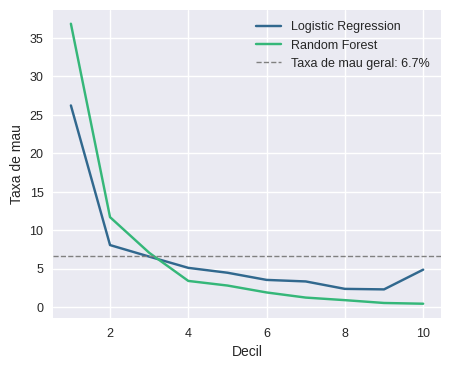

In [11]:
fig, ax = plot_percentil_bad_rate(results_percentil=results_ord,
                                  target=target,
                                  ylabel="Taxa de mau")

_save_figure(fig, "/content/drive/MyDrive/Portfolio_WL/Gains_chart/app/data/grafico_ordena.png")

In [ ]:
#
describe_gain_credit_chart(
    client=client,
    path_image="/content/drive/MyDrive/Portfolio_WL/Gains_chart/app/data/grafico_ordena.png"
)

'Ambos os modelos apresentam ordenação adequada, com maior taxa de mau nos percentis iniciais e redução consistente ao longo das faixas. O Random Forest demonstra maior separação de risco, exibindo taxas de mau mais elevadas nos percentis de maior risco e menores nos percentis de menor risco em comparação à Regressão Logística. Portanto, com base na métrica apresentada (taxa de mau), o Random Forest é superior em discriminação de risco.'

In [ ]:
def plot_percentil_lift(
    results_percentil: pd.DataFrame,
    target: pd.Series,
    figsize: Tuple[int, int] = (5, 4),
    palette: str = "viridis",
    #title: str = "Ordenação por Lift",
    xlabel: str = "Decil",
    ylabel: str = "Lift",
    title_fontsize: int = 12,
    label_fontsize: int = 10,
    tick_fontsize: int = 9,
    legend_fontsize: int = 9,
    output_path: Optional[str] = "grafico_lift.png",
) -> FigAx:
    """Plot lift by percentile for one or more models.

    Parameters
    ----------
    results : pd.DataFrame
        Output of analyze_multiple_models(), containing columns
        'percentile', 'lift', and 'model'.
    target : pd.Series
        Binary target (1 = bad, 0 = good) used to compute the average
        bad rate reference line.
    figsize : tuple, default=(5, 4)
        Figure dimensions in inches.
    palette : str, default="viridis"
        Seaborn color palette for the model lines.
    title : str, default="Ordenação por Lift"
        Chart title.
    xlabel : str, default="Percentil"
        Label for the x-axis.
    ylabel : str, default="Lift"
        Label for the y-axis.
    title_fontsize : int, default=12
        Font size for the chart title.
    label_fontsize : int, default=10
        Font size for axis labels.
    tick_fontsize : int, default=9
        Font size for axis tick labels.
    legend_fontsize : int, default=9
        Font size for legend text.
    output_path : str or None, default="grafico_lift.png"
        File path to save the figure. Pass None to skip saving.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    _validate_results_percentil(results_percentil, ["percentile", "lift", "model"])

    fig, ax = plt.subplots(figsize=figsize)

    sns.lineplot(
        data=results_percentil,
        x="percentile",
        y="lift",
        hue="model",
        palette=palette,
        ax=ax,
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    #ax.set_title(title)
    ax.legend()

    _apply_font_sizes(ax, title_fontsize, label_fontsize, tick_fontsize, legend_fontsize)
    _save_figure(fig, output_path)

    return fig, ax


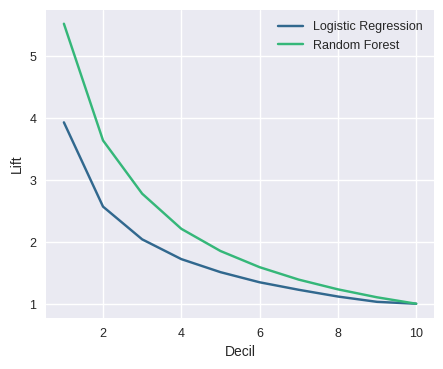

In [ ]:
fig, ax = plot_percentil_lift(results_percentil=results_ord,
                                  target=target,
                                  ylabel="Lift")

_save_figure(fig, "/content/drive/MyDrive/Portfolio_WL/Gains_chart/app/data/grafico_lift.png")

In [ ]:
describe_gain_credit_chart(
    client=client,
    path_image="/content/drive/MyDrive/Portfolio_WL/Gains_chart/app/data/grafico_lift.png"
)

'O gráfico mostra que ambos os modelos apresentam ordenação consistente de risco, com o lift decrescendo monotonicamente ao longo dos percentis. O Random Forest exibe maior lift nas faixas iniciais (maior risco) e mantém superioridade em todos os percentis em relação à Regressão Logística. Portanto, o Random Forest demonstra melhor separação de risco entre as faixas, sendo superior segundo a métrica apresentada.'

In [ ]:
def plot_percentil_gain(
    results_percentil: pd.DataFrame,
    target: pd.Series,
    figsize: Tuple[int, int] = (5, 4),
    palette: str = "viridis",
    #title: str = "Ordenação por Gain",
    xlabel: str = "Decil",
    ylabel: str = "Ganho acumulado",
    title_fontsize: int = 12,
    label_fontsize: int = 10,
    tick_fontsize: int = 9,
    legend_fontsize: int = 9,
    output_path: Optional[str] = "grafico_gain.png",
) -> FigAx:
    """Plot cumulative gain by percentile for one or more models.

    A (0, 0) origin row is added per model so the curve starts from zero,
    which is required for correct visual representation of the Lorenz curve.

    Parameters
    ----------
    results_percentil : pd.DataFrame
        Output of analyze_multiple_models(), containing columns
        'percentile', 'gain_bads_cum', and 'model'.
    target : pd.Series
        Binary target (1 = bad, 0 = good). Accepted for interface
        consistency but not used in this plot.
    figsize : tuple, default=(5, 4)
        Figure dimensions in inches.
    palette : str, default="viridis"
        Seaborn color palette for the model lines.
    title : str, default="Ordenação por Gain"
        Chart title.
    xlabel : str, default="Percentil"
        Label for the x-axis.
    ylabel : str, default="Gain"
        Label for the y-axis.
    title_fontsize : int, default=12
        Font size for the chart title.
    label_fontsize : int, default=10
        Font size for axis labels.
    tick_fontsize : int, default=9
        Font size for axis tick labels.
    legend_fontsize : int, default=9
        Font size for legend text.
    output_path : str or None, default="grafico_gain.png"
        File path to save the figure. Pass None to skip saving.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    _validate_results_percentil(results_percentil, ["percentile", "gain", "model"])

    results_percentil["gain_aux"] = results_percentil["gain"] * 100

    zeros = pd.DataFrame([
        {"percentile": 0, "gain_aux": 0, "model": model}
        for model in results_percentil["model"].unique()
    ])
    results_with_origin = (
        pd.concat([results_percentil, zeros], ignore_index=True)
        .sort_values(["model", "percentile"])
        .reset_index(drop=True)
    )

    fig, ax = plt.subplots(figsize=figsize)

    sns.lineplot(
        data=results_with_origin,
        x="percentile",
        y="gain_aux",
        hue="model",
        palette=palette,
        ax=ax,
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    #ax.set_title(title)
    ax.legend()

    _apply_font_sizes(ax, title_fontsize, label_fontsize, tick_fontsize, legend_fontsize)
    _save_figure(fig, output_path)

    return fig, ax

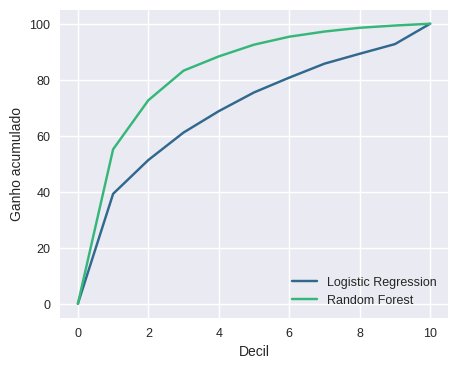

In [ ]:
fig, ax = plot_percentil_gain(results_percentil=results_ord,
                              target=target,
                              ylabel="Ganho acumulado")


_save_figure(fig, "/content/drive/MyDrive/Portfolio_WL/Gains_chart/app/data/grafico_gain.png")

In [ ]:
describe_gain_credit_chart(
    client=client,
    path_image="/content/drive/MyDrive/Portfolio_WL/Gains_chart/app/data/grafico_gain.png"
)

'O gráfico exibe a métrica de gain acumulado ao longo dos percentis de score, mostrando que ambos os modelos apresentam crescimento monotônico, indicando ordenação consistente do risco. O modelo Random Forest apresenta maior separação entre as faixas de maior e menor risco, com ganho mais acentuado nos percentis iniciais em comparação à Regressão Logística. Portanto, com base na métrica apresentada, o Random Forest demonstra desempenho superior em discriminar risco ao longo dos percentis.'

In [ ]:
def plot_percentil_bad_rate_cumrev(
    results_percentil: pd.DataFrame,
    target: pd.Series,
    n_percentiles: int = 10,
    figsize: Tuple[int, int] = (5, 4),
    palette: str = "viridis",
    #title: str = "Maus Acumulados até a Bad Média",
    xlabel: str = "Decil",
    ylabel: str = "Taxa de mau acumulada",
    title_fontsize: int = 12,
    label_fontsize: int = 10,
    tick_fontsize: int = 9,
    legend_fontsize: int = 9,
    output_path: Optional[str] = "grafico_bad_media.png",
) -> FigAx:
    """Plot reverse cumulative bad rate by percentile for one or more models.

    The cutoff line is placed at n_percentiles // 2. A warning is emitted
    if n_percentiles is odd, since the midpoint will be rounded down.

    Parameters
    ----------
    results_percentil : pd.DataFrame
        Output of analyze_multiple_models(), containing columns
        'percentile', 'bad_rate_cum_rev', and 'model'.
    target : pd.Series
        Binary target (1 = bad, 0 = good). Accepted for interface
        consistency but not used in this plot.
    n_percentiles : int, default=10
        Total number of percentiles used in the analysis. Determines the
        position of the vertical cutoff line (n_percentiles // 2).
    figsize : tuple, default=(5, 4)
        Figure dimensions in inches.
    palette : str, default="viridis"
        Seaborn color palette for the model lines.
    title : str, default="Maus Acumulados até a Bad Média"
        Chart title.
    xlabel : str, default="Percentil"
        Label for the x-axis.
    ylabel : str, default=""
        Label for the y-axis.
    title_fontsize : int, default=12
        Font size for the chart title.
    label_fontsize : int, default=10
        Font size for axis labels.
    tick_fontsize : int, default=9
        Font size for axis tick labels.
    legend_fontsize : int, default=9
        Font size for legend text.
    output_path : str or None, default="grafico_bad_media.png"
        File path to save the figure. Pass None to skip saving.

    Returns
    -------
    fig, ax : matplotlib Figure and Axes
    """
    _validate_results_percentil(results_percentil, ["percentile", "bad_rate_cum_rev", "model"])

    results_percentil["bad_rate_cum_rev_aux"] = results_percentil["bad_rate_cum_rev"] * 100

    cutoff = _compute_cutoff(n_percentiles)

    cutoff_data = results_percentil[results_percentil["percentile"] == cutoff][
        ["model", "bad_rate_cum_rev_aux"]
    ]

    fig, ax = plt.subplots(figsize=figsize)

    sns.lineplot(
        data=results_percentil,
        x="percentile",
        y="bad_rate_cum_rev_aux",
        hue="model",
        palette=palette,
        ax=ax,
    )

    ax.axvline(
        x=cutoff,
        color="gray",
        linestyle="--",
        linewidth=1,
        label=f"Corte no decil {cutoff}"
    )

    # Get unique models and their assigned colors from the palette for annotation consistency
    model_names = results_percentil["model"].unique().tolist()
    colors = sns.color_palette(palette)
    model_color_map = {model: colors[i] for i, model in enumerate(model_names)}

    for _, row in cutoff_data.iterrows():
        model = row['model']
        bad_rate_val = row['bad_rate_cum_rev_aux']
        ax.annotate(
            f"{bad_rate_val/100:.2%}",
            xy=(cutoff, bad_rate_val-0.15),
            xytext=(5, 0),  # Offset text slightly to the right of the point
            textcoords="offset points",
            ha="left",
            va="center",
            fontsize=tick_fontsize
        )

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    #ax.set_title(title)
    ax.invert_xaxis()
    ax.legend()

    _apply_font_sizes(ax, title_fontsize, label_fontsize, tick_fontsize, legend_fontsize)
    _save_figure(fig, output_path)

    return fig, ax

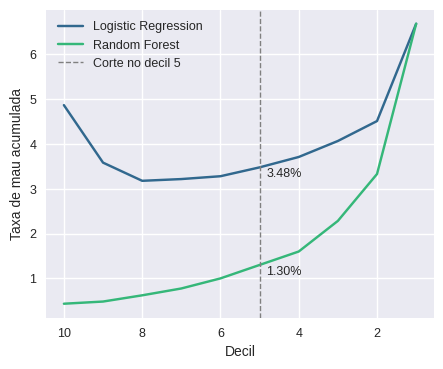

In [ ]:
fig, ax = plot_percentil_bad_rate_cumrev(results_percentil=results_ord,
                                 target=target#,
                                 #ylabel="Bad rate"
                                         )

_save_figure(fig, "/content/drive/MyDrive/Portfolio_WL/Gains_chart/app/data/grafico_mean_bad.png")

In [ ]:
describe_gain_credit_chart(
    client=client,
    path_image="/content/drive/MyDrive/Portfolio_WL/Gains_chart/app/data/grafico_mean_bad.png"
)

'O modelo Random Forest apresenta maior separação de risco entre os percentis, com taxas de maus (bad rate) significativamente menores nas faixas de menor risco e maiores nas faixas de maior risco, em comparação à Regressão Logística. Observa-se que a curva do Random Forest mantém uma tendência crescente mais acentuada e consistente ao longo dos percentis, enquanto a Regressão Logística apresenta menor variação entre as faixas. Portanto, com base na métrica de bad rate, o Random Forest demonstra ordenação e discriminação superiores entre os grupos de risco.'

# Código original

In [ ]:
# --- Ordenação Relativa ---
fig, ax = plt.subplots(figsize=(5, 4))

sns.lineplot(data=results_ord, x="percentile", y="bad_rate",
             hue="model", palette="viridis")

taxa_media = target.mean()
ax.axhline(y=taxa_media, color="gray", linestyle='--', linewidth=1,
           label=f'Bad rate Média ({taxa_media:.2%})')

ax.set_xlabel('Percentil')
ax.set_ylabel('Taxa de Mau')
ax.set_title('Ordenação Relativa')
ax.legend()
fig.savefig('grafico_ordena.png', dpi=300, bbox_inches='tight')


In [ ]:
# --- Lift ---
fig, ax = plt.subplots(figsize=(5, 4))

sns.lineplot(data=results_ord, x="percentile", y="lift",
             hue="model", palette="viridis")

ax.set_xlabel('Percentil')
ax.set_ylabel('Lift')
ax.set_title('Ordenação por Lift')
ax.legend()
fig.savefig('grafico_lift.png', dpi=300, bbox_inches='tight')


In [ ]:
# --- Gain ---
zeros = pd.DataFrame([
    {'percentile_rev': 0, 'gain': 0, 'model': modelo}
    for modelo in results_ord['model'].unique()
])
results_com_zero = (
    pd.concat([zeros, results_ord], ignore_index=True)
      .sort_values(['model', 'percentile_rev'])
      .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(5, 4))

sns.lineplot(data=results_com_zero, x="percentile_rev", y="gain",
             hue="model", palette="viridis")

ax.set_xlabel('Percentil')
ax.set_ylabel('Gain')
ax.set_title('Ordenação por Gain')
ax.legend()
fig.savefig('grafico_gain.png', dpi=300, bbox_inches='tight')

In [ ]:

# --- Maus Acumulados até a Bad Média ---
corte = n_percentiles // 2  # dinâmico: metade dos percentis

fig, ax = plt.subplots(figsize=(5, 4))

sns.lineplot(data=results_ord, x="percentile", y="bad_rate_cum",
             hue="model", palette="viridis")

p_corte = results_ord[results_ord['percentile'] == corte][['model', 'bad_rate_cum']]
ax.axvline(x=corte, color="gray", linestyle='--', linewidth=1,
           label=(f'Corte em p{corte}\n'
                  f'{p_corte.iloc[0, 0]}: {p_corte.iloc[0, 1]:.2%}\n'
                  f'{p_corte.iloc[1, 0]}: {p_corte.iloc[1, 1]:.2%}'))

ax.set_xlabel('Percentil')
ax.set_ylabel('')
ax.set_title('Maus Acumulados até a Bad Média')
ax.legend()
fig.savefig('grafico_bad_media.png', dpi=300, bbox_inches='tight')


In [ ]:
# --- Curva ROC / Gini ---
roc_data = compute_roc_curves(scores_dict, target)

fig, ax = plt.subplots(figsize=(5, 4))

for model_name, df_roc in roc_data.items():
    gini = df_roc["gini"].iloc[0]
    ax.plot(df_roc["fpr"], df_roc["tpr"], label=f"{model_name} (Gini={gini:.2%})")

ax.plot([0, 1], [0, 1], '--', color='gray', label='Aleatório')
ax.set_xlabel('Falsos Positivos (FPR)')
ax.set_ylabel('Verdadeiros Positivos (TPR)')
ax.set_title('Curva ROC')
ax.legend()
fig.savefig('grafico_roc.png', dpi=300, bbox_inches='tight')


In [ ]:
ks_data = compute_ks_curves(scores_dict, target)

n_models = len(ks_data)
fig, axes = plt.subplots(1, n_models, figsize=(6*n_models, 4), sharey=True)

if n_models == 1:
    axes = [axes]

for ax, (model_name, df_ks) in zip(axes, ks_data.items()):
    df_ks = df_ks.sort_values("score")

    ks_val = df_ks["ks_spread"].max()
    ks_row = df_ks.loc[df_ks["ks_spread"].idxmax()]

    ax.plot(df_ks["score"], df_ks["cum_bads_pct"],
            linestyle='-', label="Eventos")
    ax.plot(df_ks["score"], df_ks["cum_goods_pct"],
            linestyle='--', label="Não Eventos")

    # ----------------------------------------
    ax.vlines(ks_row["score"],
              ymin=ks_row["cum_goods_pct"],
              ymax=ks_row["cum_bads_pct"],
              linestyles=':')

    # ----------------------------------------
    ax.annotate(f"KS = {ks_val:.2%}",
                xy=(ks_row["score"], ks_row["cum_bads_pct"]),
                xytext=(10, 10),
                textcoords="offset points",
                fontsize=9,
                bbox=dict(boxstyle="round,pad=0.3", alpha=0.2))

    ax.set_title(model_name)
    ax.set_xlabel('Score')
    ax.grid(alpha=0.2)

axes[0].set_ylabel('% Acumulada')

# ----------------------------------------
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2)

plt.tight_layout(rect=[0, 0.1, 1, 1])
fig.savefig('grafico_ks.png', dpi=300, bbox_inches='tight')